In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torchvision.transforms as transforms
import torchvision.models as models
from torch.utils.data import DataLoader, Dataset, random_split,Subset
from torchvision.datasets import ImageFolder
from sklearn.metrics import  confusion_matrix
from torch.utils.data.sampler import WeightedRandomSampler
from torchsummary import summary
import torchvision.transforms as transforms
from torchvision.datasets import CIFAR10,Flowers102


/home/pcdm/anaconda3/envs/ming/lib/python3.11/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
transform=transforms.Compose([
   
    transforms.RandomHorizontalFlip(),
    transforms.Resize((224,224)),
    transforms.ToTensor(),             
])

In [3]:
DATA_DIR = r'/home/pcdm/Desktop/flower/flower_data/train'
model_algo="alexnet"

In [4]:
import sys

# 添加自定义模块的目录到模块搜索路径
sys.path.append('/home/pcdm/Desktop')

# 现在可以导入你的自定义模块
from MJPytorch import *

In [5]:
#讀取資料且切分資料為train、valid、test

images=ImageDataset(DATA_DIR,transform)

generator = torch.Generator()
generator.manual_seed(124)

size = len(images)
valid_size = int(0.2 * size)

train_size = int(size - valid_size )

trainset, validset= random_split(images, (train_size, valid_size), generator=generator)


In [6]:
valid_size

1474

In [7]:
train_size

5896

In [8]:
# create data loaders
batch_size =32 # larger numbers lead to CUDA running out of memory
train_dl = DataLoader(trainset,shuffle=True, batch_size=batch_size)
valid_dl = DataLoader(validset,shuffle=True, batch_size=batch_size)
criterion = nn.CrossEntropyLoss()

/home/pcdm/anaconda3/envs/ming/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch=0,train_loss=0.5214839356482595,train_accu=0.851763907734057
Epoch=0,valid_loss=0.7186211057391467,valid_accu=0.7964721845318861
0
Epoch=1,train_loss=0.3082866407021011,train_accu=0.9135006784260515
Epoch=1,valid_loss=0.6277693851751097,valid_accu=0.8188602442333786
0
Epoch=2,train_loss=0.1482431626141961,train_accu=0.9598032564450475
Epoch=2,valid_loss=0.5064681974508809,valid_accu=0.841248303934871
0
Epoch=3,train_loss=0.07874082561248719,train_accu=0.9782903663500678
Epoch=3,valid_loss=0.45952834109579854,valid_accu=0.8622795115332429
0
Epoch=4,train_loss=0.048683362806044024,train_accu=0.9869402985074627
Epoch=4,valid_loss=0.44825019945107464,valid_accu=0.8616010854816825
Epoch=5,train_loss=0.06257628619777016,train_accu=0.98219131614654
Epoch=5,valid_loss=0.4972524871200505,valid_accu=0.8738127544097694
0
Epoch=6,train_loss=0.039525425864643894,train_accu=0.9899932157394844
Epoch=6,valid_loss=0.46218250520032006,valid_accu=0.8697421981004071
Epoch=7,train_loss=0.027266805213

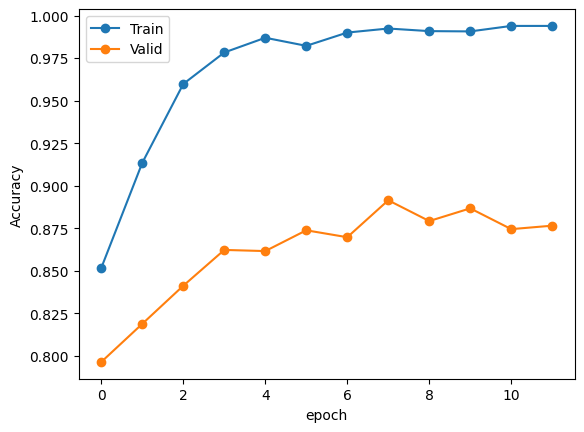

In [9]:
model_0=model_train(model_algo,train_dl,valid_dl,"0",70)
# model_0 = torch.load(f'model_{model_algo}_0_4.pth')

In [10]:
train_loss,train_accu,confusion_matrix_train=evaluate_model(model_0,train_dl,train_size,'0',mode='eval')
train_loss,train_accu

(0.02713723705697355, 0.9927069199457259)

In [11]:
valid_loss,valid_accu,confusion_matrix_valid=evaluate_model(model_0,valid_dl,valid_size,'0',mode='eval')
valid_loss,valid_accu

(0.44614954426217435, 0.8887381275440976)

In [12]:
r=np.diag(confusion_matrix_train)/confusion_matrix_train.sum(0)
p=np.diag(confusion_matrix_train)/confusion_matrix_train.sum(1)

In [13]:
each_accu=2*p*r/(p+r)
each_accu

1      1.000000
10     0.986301
100    1.000000
101    0.979167
102    1.000000
         ...   
95     0.984456
96     0.970149
97     0.989691
98     1.000000
99     1.000000
Length: 102, dtype: float64

In [14]:
# each_accu=np.diag(confusion_matrix_train)/confusion_matrix_train.sum(1)
# each_accu

In [15]:
targetF=[x  for x in each_accu.nsmallest(4).index.map(trainset.dataset.classess)]
targetF

[31, 29, 45, 51]

In [16]:
#將資料切分後建立dataset與dataloader
indexF=[]
indexT=[]

split_mode=('classaccu',targetF)
indexF,indexT=split_data(model_0,train_dl,split_mode)

Fdataset=Subset(images, indexF)
Tdataset=Subset(images, indexT)

Fdl=DataLoader(Fdataset, shuffle=True, batch_size=batch_size)
Tdl=DataLoader(Tdataset, shuffle=True, batch_size=batch_size)

len(indexF),len(indexT)

(170, 5726)

In [17]:
indexF_v=[]
indexT_v=[]

indexF_v,indexT_v=split_data(model_0,valid_dl,split_mode)
len(indexF_v),len(indexT_v)

(50, 1424)

In [18]:
d_data,d_target=decision_split(train_dl,model_0)
d_v_data,d_v_target=decision_split(valid_dl,model_0)

In [19]:
decisionset=DecisionDataset(d_data,d_target)
decisionset_v=DecisionDataset(d_v_data,d_v_target)

In [20]:
#將模型建立框架後並訓練
def model_train(model_algo,train_dl,valid_dl,data_name,epochs,model_0=None):

    if(data_name=="decision"):
        # model=model_create(model_algo,data_name,2)
        model=copy.deepcopy(model_0)
        model.classifier[6]=nn.Linear(model.classifier[6].in_features,2)
    elif(data_name=='T'or data_name=='F'):
        model=copy.deepcopy(model_0)
        model.classifier[6]=nn.Linear(model.classifier[6].in_features,len(train_dl.dataset.dataset.classes))

    else:
        model=model_create(model_algo,data_name,len(train_dl.dataset.dataset.classes))

    if(model_algo=='googlenet' or model_algo=='resnet18' or model_algo=='inception_v3' ):
        model_fc_layer=model.fc
    # elif(model_algo=='efficientnet_b7' or model_algo=='mobilenet_v2'):
    #     model_fc_layer=model.classifier[1]
    else:
        model_fc_layer=model.classifier[6]


    if(data_name=="decision"):
        optim = torch.optim.Adam(model.classifier[6].parameters(), lr=1e-4)
        criterion = nn.CrossEntropyLoss() 
        model=trainer(epochs,model,criterion,optim,train_dl,valid_dl,data_name,model_algo)
    else:   
        optim = torch.optim.Adam(model.classifier.parameters(), lr=1e-4)
        criterion = nn.CrossEntropyLoss()
        model=trainer(epochs,model,criterion,optim,train_dl,valid_dl,data_name,model_algo)
    torch.cuda.empty_cache() 
    return model

Epoch=0,train_loss=0.036285151589757876,train_accu=0.9903324287652646
Epoch=0,valid_loss=0.05751866022354874,valid_accu=0.9810040705563093
0
Epoch=1,train_loss=0.022239480008405293,train_accu=0.9942333785617368
Epoch=1,valid_loss=0.045670501432878194,valid_accu=0.9850746268656716
0
Epoch=2,train_loss=0.01563304361003973,train_accu=0.9972862957937585
Epoch=2,valid_loss=0.03794908814202979,valid_accu=0.9871099050203528
0
Epoch=3,train_loss=0.01423292464969662,train_accu=0.9979647218453188
Epoch=3,valid_loss=0.036911806271106934,valid_accu=0.9884667571234735
0
Epoch=4,train_loss=0.009429435452144325,train_accu=0.9988127544097694
Epoch=4,valid_loss=0.03151204290179336,valid_accu=0.989145183175034
0
Epoch=5,train_loss=0.012600059410635498,train_accu=0.9971166892808684
Epoch=5,valid_loss=0.037333945186462464,valid_accu=0.9871099050203528
Epoch=6,train_loss=0.009553310915630619,train_accu=0.9988127544097694
Epoch=6,valid_loss=0.03290720942608375,valid_accu=0.9884667571234735
Epoch=7,train_los

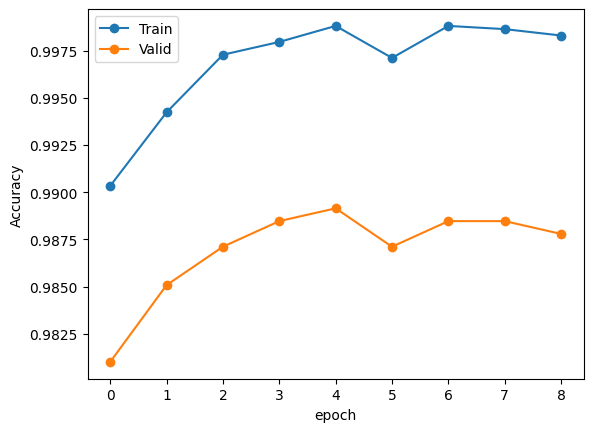

In [21]:
from torchsampler import ImbalancedDatasetSampler
decision_dl = DataLoader(decisionset, batch_size=32)
# decision_dl = DataLoader(decisionset, batch_size=32,sampler=ImbalancedDatasetSampler(decisionset))
decision_v_dl = DataLoader(decisionset_v, batch_size=32)
model_decision=model_train(model_algo,decision_dl,decision_v_dl,"decision",70,model_0=model_0)

In [22]:
Fdataset_v=Subset(images, indexF_v)
Tdataset_v=Subset(images, indexT_v)

Fdl_v=DataLoader(Fdataset_v, shuffle=True, batch_size=batch_size)
Tdl_v=DataLoader(Tdataset_v, shuffle=True, batch_size=batch_size)

Epoch=0,train_loss=0.07713283554963453,train_accu=0.9823611596227733
Epoch=0,valid_loss=0.40909682900718086,valid_accu=0.8946629213483146
0
Epoch=1,train_loss=0.02089141644511425,train_accu=0.9970310862731401
Epoch=1,valid_loss=0.3894006216040488,valid_accu=0.9023876404494382
0
Epoch=2,train_loss=0.016007651339883296,train_accu=0.997205728257073
Epoch=2,valid_loss=0.39713788761370133,valid_accu=0.8974719101123596
Epoch=3,train_loss=0.011400969243448043,train_accu=0.9968564442892072
Epoch=3,valid_loss=0.39016124999590135,valid_accu=0.9044943820224719
0
Epoch=4,train_loss=0.0062751061520680725,train_accu=0.9991267900803353
Epoch=4,valid_loss=0.3776266121546204,valid_accu=0.9037921348314607
Epoch=5,train_loss=0.020387978498812392,train_accu=0.9951100244498777
Epoch=5,valid_loss=0.4149832466847441,valid_accu=0.9051966292134831
0
Epoch=6,train_loss=0.009343558618176886,train_accu=0.9975550122249389
Epoch=6,valid_loss=0.41221180127075546,valid_accu=0.9030898876404494
Epoch=7,train_loss=0.015

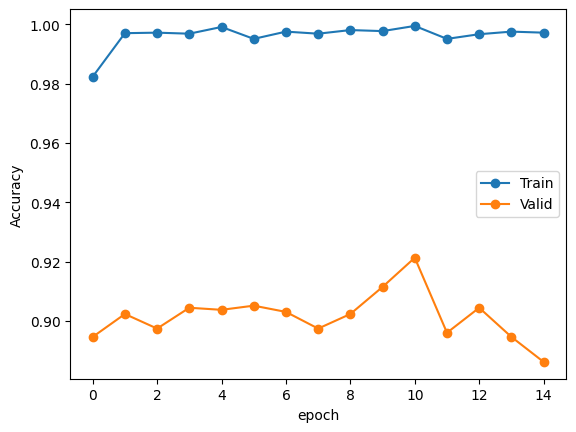

In [23]:
#訓練模型T、F、decision
model_T=model_train(model_algo,Tdl,Tdl_v,"T",70,model_0=model_0)
# model_T=torch.load(f'model_{model_algo}_T_1.pth')

Epoch=0,train_loss=0.036508797859663475,train_accu=0.9941176470588236
Epoch=0,valid_loss=0.04673674762248993,valid_accu=0.98
0
Epoch=1,train_loss=0.005087397681371145,train_accu=1.0
Epoch=1,valid_loss=0.0076476107910275455,valid_accu=1.0
0
Epoch=2,train_loss=0.0003789456007485997,train_accu=1.0
Epoch=2,valid_loss=0.003801719341427088,valid_accu=1.0
Epoch=3,train_loss=0.0018957883403452477,train_accu=1.0
Epoch=3,valid_loss=0.0032323442302003968,valid_accu=1.0
Epoch=4,train_loss=0.0015446732376243315,train_accu=1.0
Epoch=4,valid_loss=0.0023717787116765976,valid_accu=1.0
Epoch=5,train_loss=5.18378520877484e-05,train_accu=1.0
Epoch=5,valid_loss=0.008584163134219124,valid_accu=1.0
4 Early stopping!


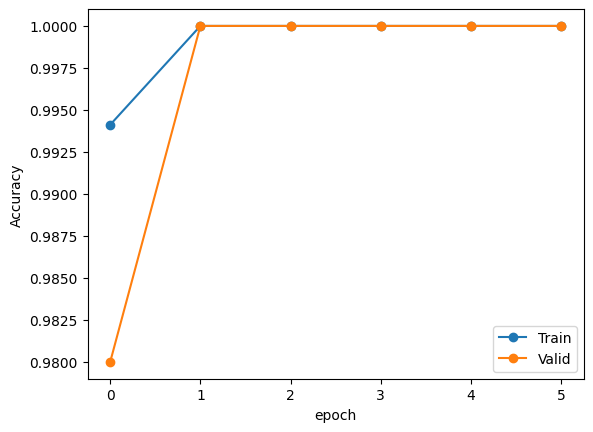

In [24]:
model_F=model_train(model_algo,Fdl,Fdl_v,"F",70,model_0=model_0)
#model_F=torch.load(f'model_{model_algo}_F_0.pth')

In [25]:
decision_loss,decision_accu,confusion_matrix_decision_train=evaluate_model(model_decision,decision_dl,len(decisionset),'decision',mode='eval')
confusion_matrix_decision_train= confusion_matrix_decision_train.rename(columns={"0":"False","1":"True"}, index={"0":"False","1":"True"})
decision_loss,decision_accu

(0.009429435452144325, 0.9988127544097694)

In [26]:
decision_valid_loss,decision_valid_accu,confusion_matrix_decision_valid=evaluate_model(model_decision,decision_v_dl,len(decisionset_v),'decision',mode='eval')
confusion_matrix_decision_valid= confusion_matrix_decision_valid.rename(columns={0:"False",1:"True"}, index={0:"False",1:"True"})
decision_valid_loss,decision_valid_accu

(0.03151204290179336, 0.989145183175034)

In [27]:
T_loss,T_accu,confusion_matrix_T_train=evaluate_model(model_T,Tdl,len(Tdataset),'T',mode='eval')
T_loss,T_accu

(0.001795306302476697, 0.9994760740482012)

In [28]:
F_loss,F_accu,confusion_matrix_F_train=evaluate_model(model_F,Fdl,len(Fdataset),'F',mode='eval')
F_loss,F_accu

(0.005226203204716405, 1.0)

In [29]:
T_valid_loss,T_valid_accu,confusion_matrix_T_valid=evaluate_model(model_T,Tdl_v,len(Tdataset_v),'T',mode='eval')
T_valid_loss,T_valid_accu

(0.3598177159320186, 0.9192415730337079)

In [30]:
F_valid_loss,F_valid_accu,confusion_matrix_F_valid=evaluate_model(model_F,Fdl_v,len(Fdataset_v),'F',mode='eval')
F_valid_loss,F_valid_accu

(0.022206909130327402, 0.98)

In [31]:
total_train_loss_d,total_train_accu_d,confusion_matrix_total_train,sum=total_model_evaluate_notdecision(train_dl,train_size,model_0,model_T,model_F)
total_train_loss_d,total_train_accu_d

(0.0019366585617089514, 0.9994911804613297)

In [32]:
total_valid_loss_d,total_valid_accu_d,confusion_matrix_total_valid_d,sum=total_model_evaluate_notdecision(valid_dl,valid_size,model_0,model_T,model_F)
total_valid_loss_d,total_valid_accu_d,sum

(0.3624004144398458, 0.923337856173677, 50)

In [33]:
total_train_loss,total_train_accu,confusion_matrix_total_train,sum_F,sum_T=total_model_evaluate(train_dl,train_size,model_0,model_T,model_F,model_decision)
total_train_loss,total_train_accu,sum_F,sum_T

(0.026419831948251614, 0.9981343283582089, 170, 5726)

In [34]:
total_valid_loss,total_valid_accu,confusion_matrix_total_valid,sum_F,sum_T=total_model_evaluate(valid_dl,valid_size,model_0,model_T,model_F,model_decision)
total_valid_loss,total_valid_accu,sum_F,sum_T

(0.5363902434090019, 0.9145183175033921, 51, 1423)

In [35]:
train_losses=[train_loss,decision_loss,T_loss,F_loss,total_train_loss,total_train_loss_d]
train_accuracies=[train_accu,decision_accu,T_accu,F_accu,total_train_accu,total_train_accu_d]
valid_losses=[valid_loss,decision_valid_loss,T_valid_loss,F_valid_loss,total_valid_loss,total_valid_loss_d]
valid_accuracies=[valid_accu,decision_valid_accu,T_valid_accu,F_valid_accu,total_valid_accu,total_valid_accu_d]

In [36]:
model_algos=['Model_0','Model_Decision',"Model_T","Model_F","Total_Model",'Total_Model_with_perfect_decision']
data = {
    'Model': model_algos,
    'Train Loss': train_losses,
    'Train Accuracy': train_accuracies,
    'Valid Loss': valid_losses,
    'Valid Accuracy': valid_accuracies
}
df = pd.DataFrame(data)
print(f'splitmode={split_mode}')
df

splitmode=('classaccu', [31, 29, 45, 51])


,Model,Train Loss,Train Accuracy,Valid Loss,Valid Accuracy
0,Model_0,0.027137,0.992707,0.446150,0.888738
1,Model_Decision,0.009429,0.998813,0.031512,0.989145
2,Model_T,0.001795,0.999476,0.359818,0.919242
3,Model_F,0.005226,1.000000,0.022207,0.980000
4,Total_Model,0.026420,0.998134,0.536390,0.914518
5,Total_Model_with_perfect_decision,0.001937,0.999491,0.362400,0.923338


In [37]:
def calculate_confusion(confusion_matrix, N):
    n_classes = confusion_matrix.shape[0]
    confusion_degrees = np.zeros((n_classes, n_classes), dtype=float)
    for i in range(n_classes):
        for j in range(n_classes):
            if i != j:
                degree = (confusion_matrix.iloc[i, j] / np.sum(confusion_matrix.iloc[i])) + \
                        (confusion_matrix.iloc[j, i] / np.sum(confusion_matrix.iloc[j]))
                confusion_degrees[i, j] = degree
    
    # 只检查下三角的元素
    indices = np.tril_indices_from(confusion_degrees, k=-1)
    flat_indices = np.argsort(confusion_degrees[indices])[::-1]
    row_indices = indices[0][flat_indices]
    col_indices = indices[1][flat_indices]
    
    top_elements = confusion_degrees[row_indices, col_indices]
    top_positions = list(zip(row_indices, col_indices))

    print("Top", N, "Elements:")
    print(top_elements[:N])
    print("Top", N, "Positions:")
    print(top_positions[:N])
    
    return top_elements, top_positions

In [38]:
top_elements, top_positions=calculate_confusion(confusion_matrix_train,N=15)

Top 15 Elements:
[0.12903226 0.04081633 0.03333333 0.02941176 0.02702703 0.02564103
 0.02439024 0.02439024 0.02325581 0.02255639 0.02040816 0.01960784
 0.01960784 0.01851852 0.01851852]
Top 15 Positions:
[(31, 29), (51, 39), (58, 18), (96, 95), (31, 1), (61, 45), (34, 17), (97, 36), (47, 38), (98, 73), (45, 39), (89, 37), (89, 32), (24, 18), (31, 24)]


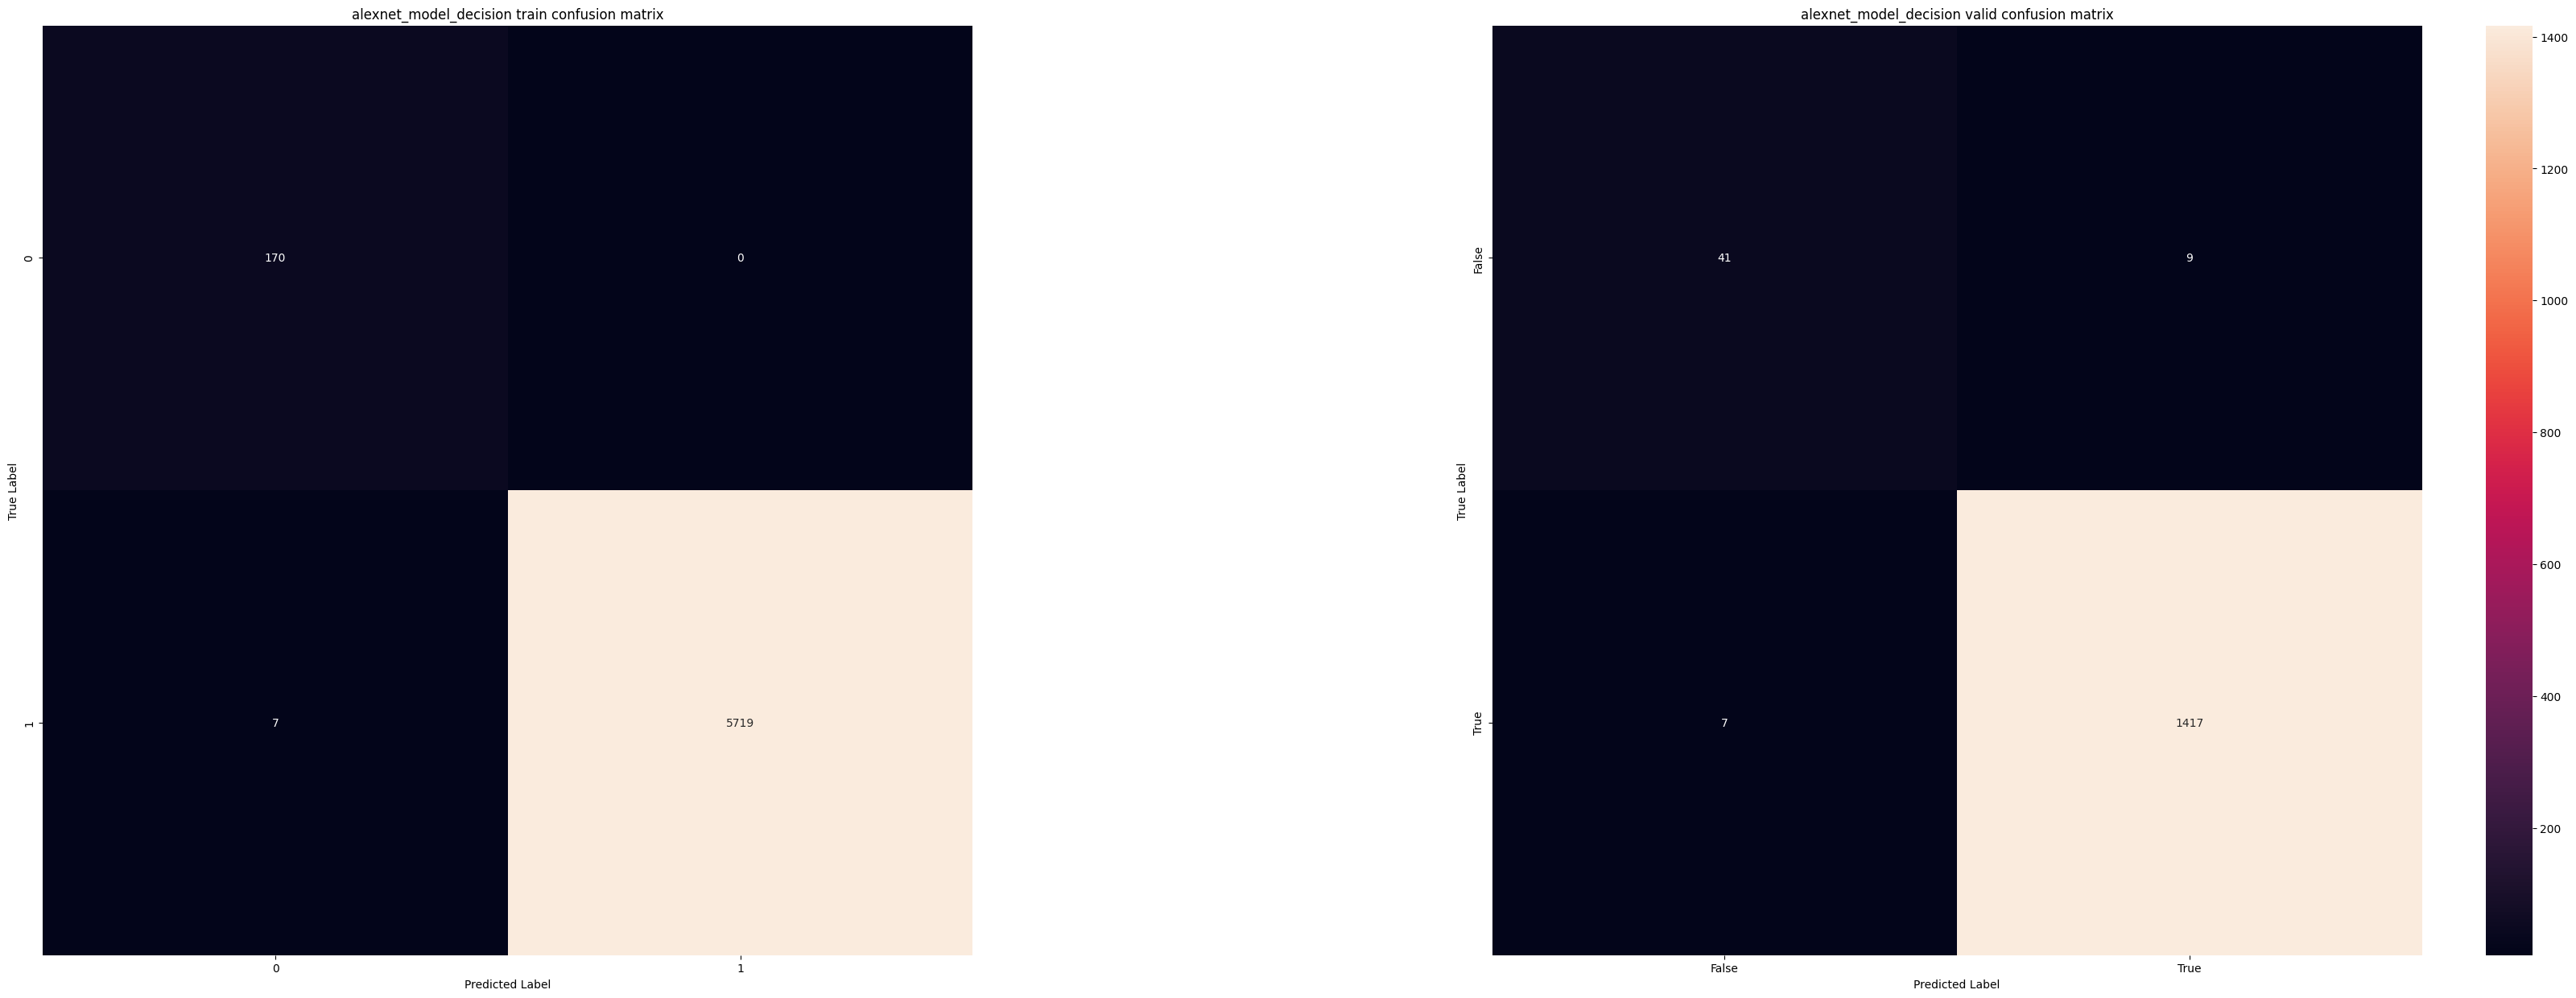

In [39]:
plot_confusion_matrix(confusion_matrix_decision_train,confusion_matrix_decision_valid,"model_decision",model_algo)

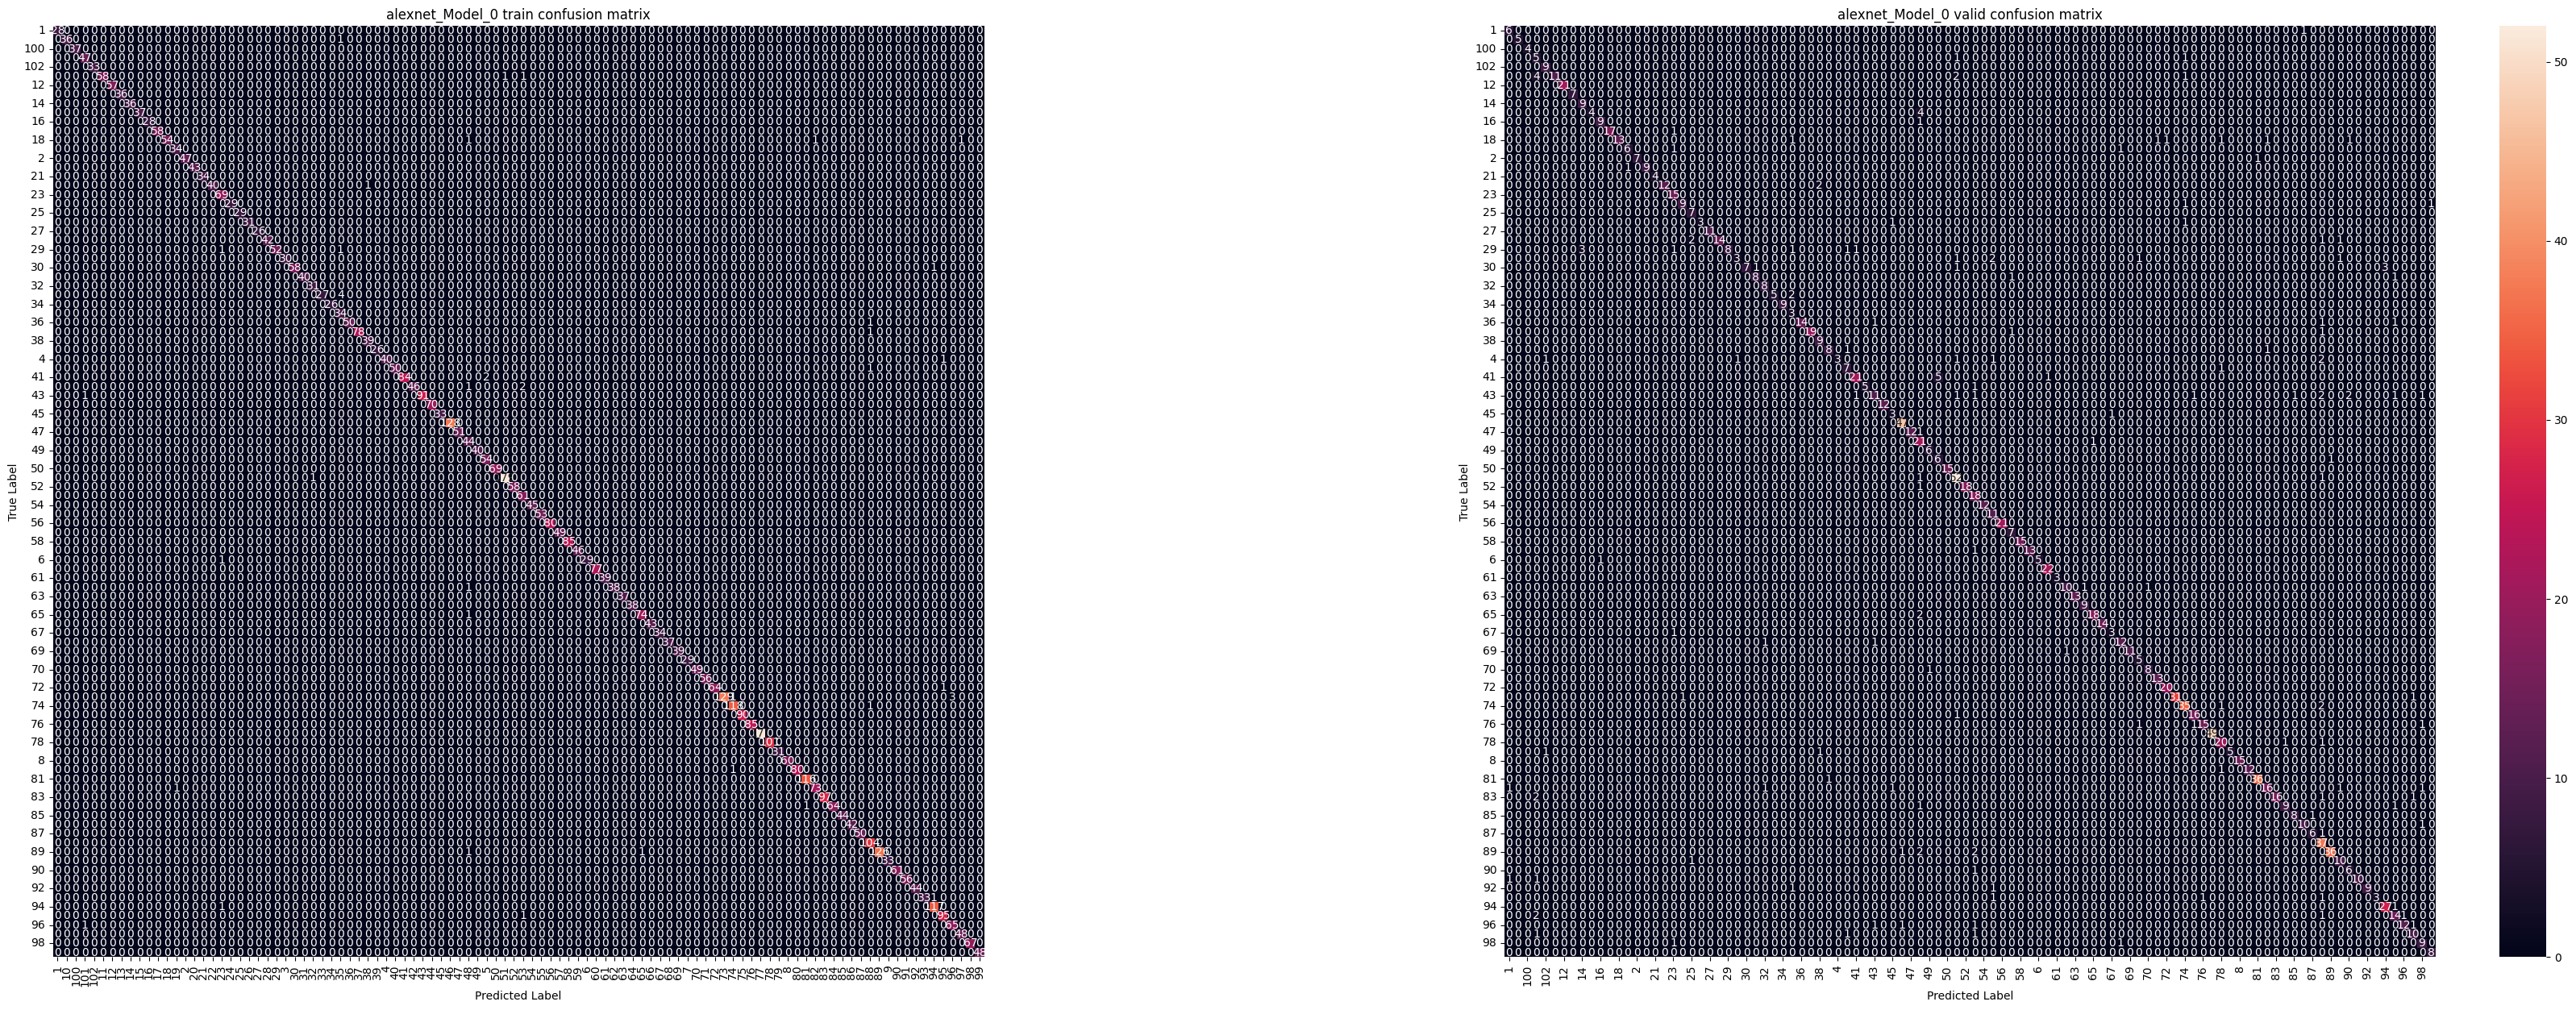

In [40]:
plot_confusion_matrix(confusion_matrix_train,confusion_matrix_valid,"Model_0",model_algo)

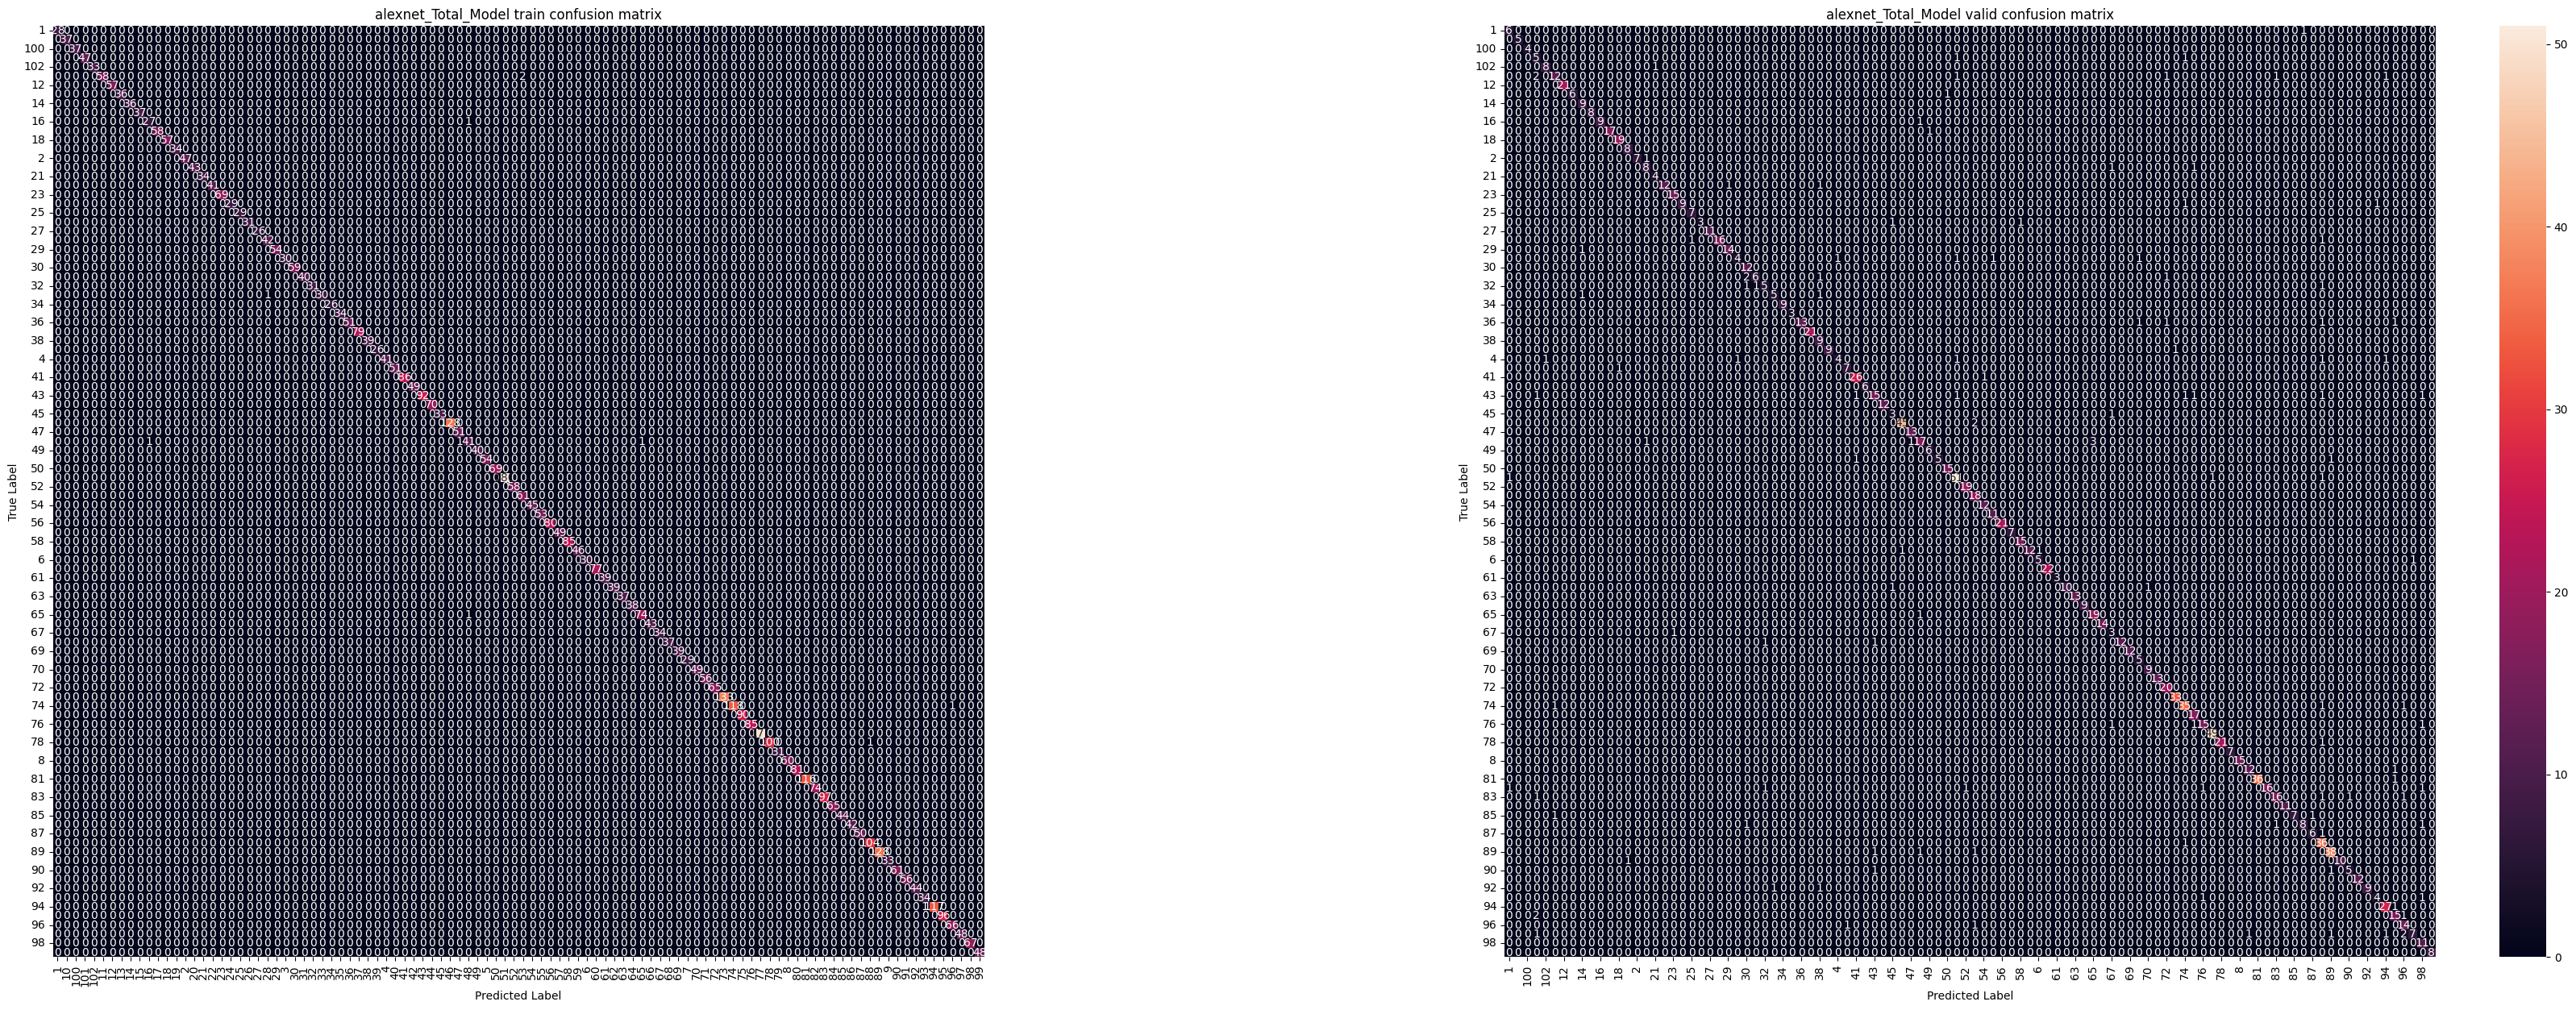

In [41]:
plot_confusion_matrix(confusion_matrix_total_train,confusion_matrix_total_valid,"Total_Model",model_algo)

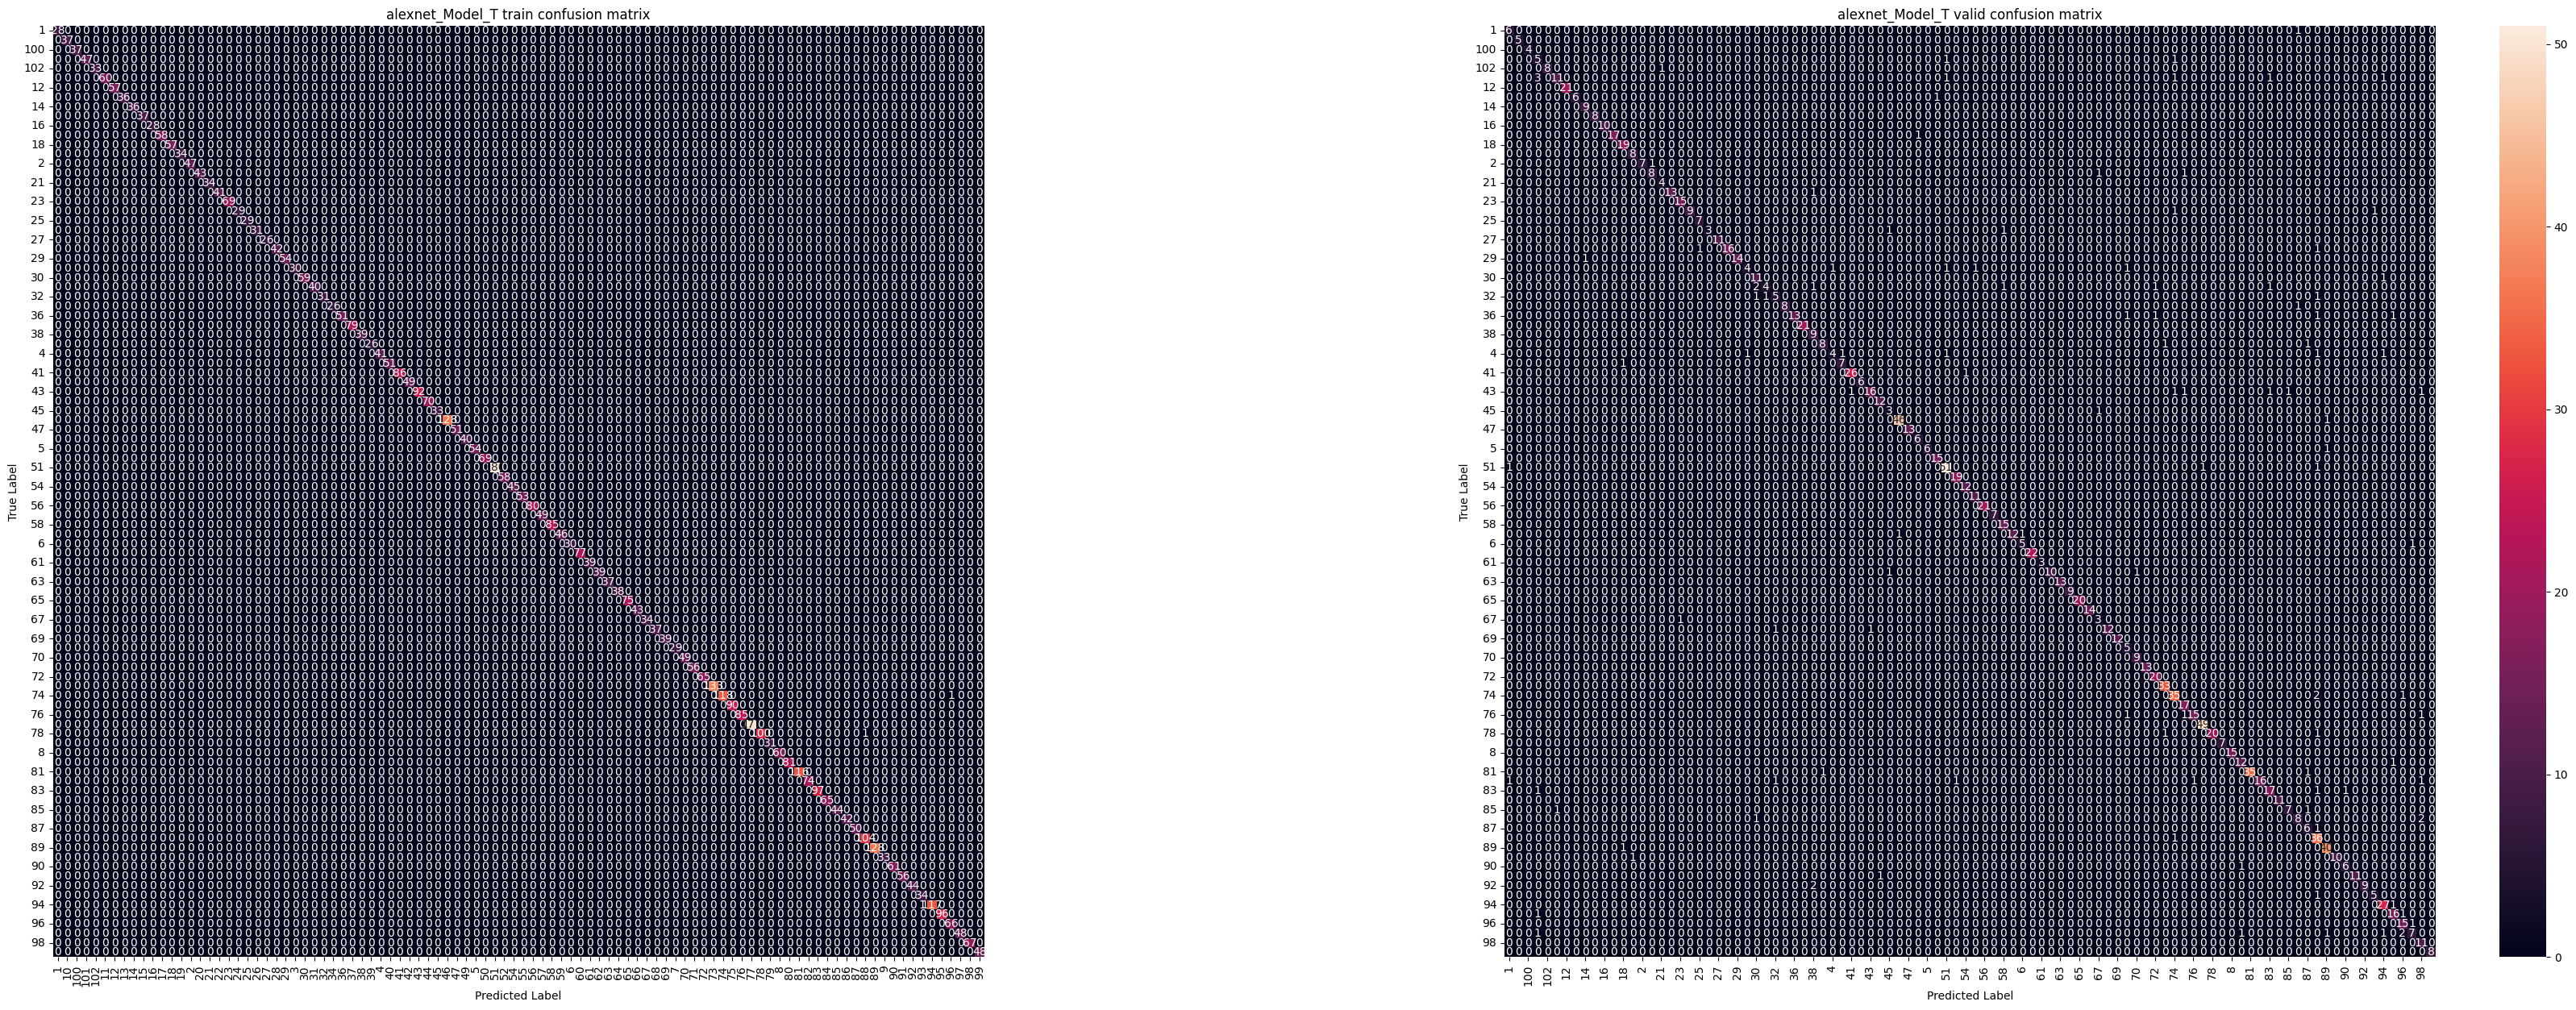

In [42]:
plot_confusion_matrix(confusion_matrix_T_train,confusion_matrix_T_valid,"Model_T",model_algo)

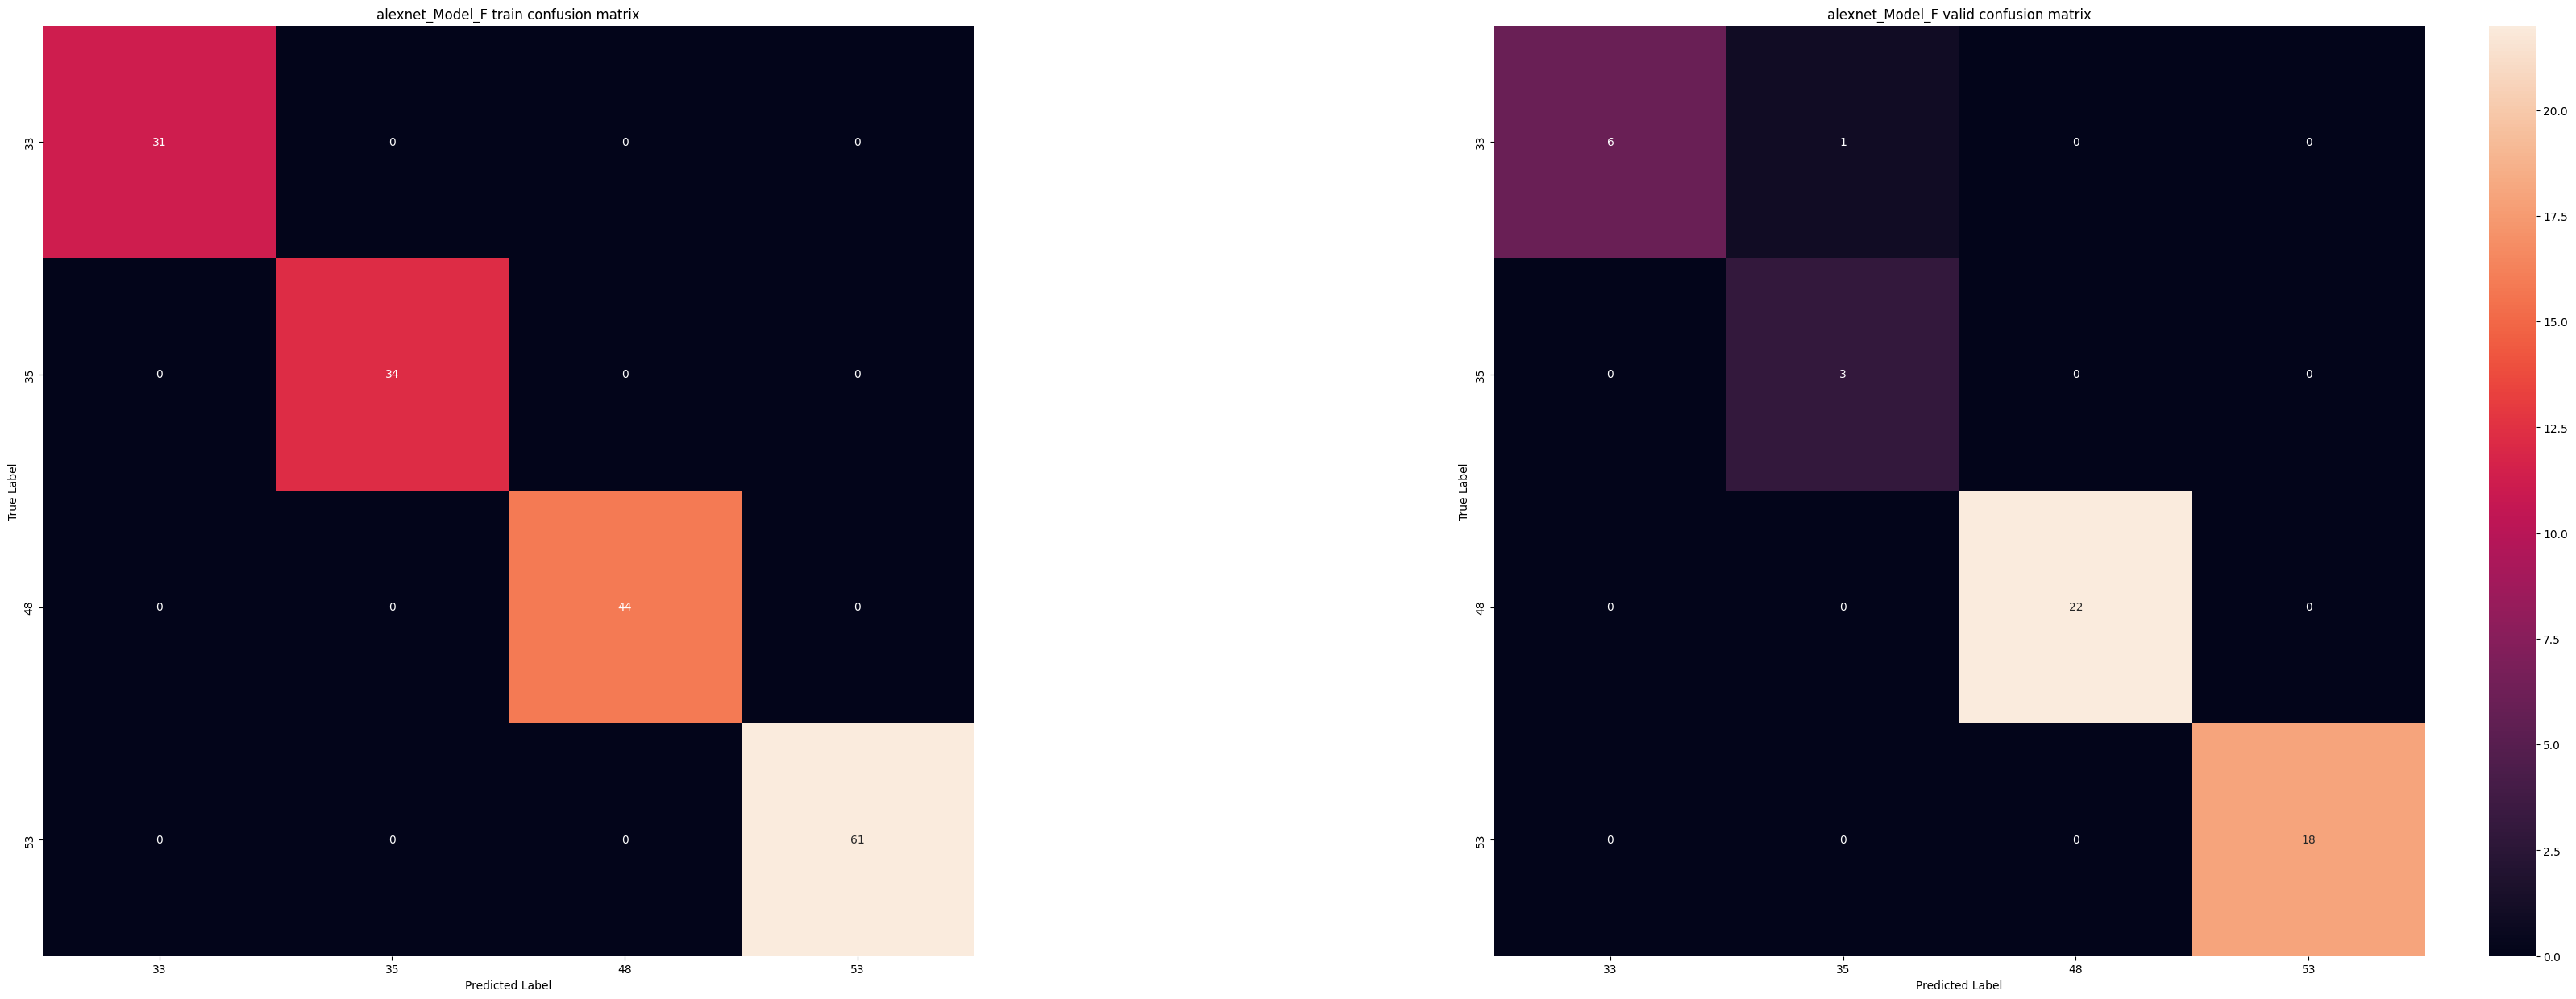

In [43]:
plot_confusion_matrix(confusion_matrix_F_train,confusion_matrix_F_valid,"Model_F",model_algo)

In [44]:
def show_model_evaluate(data_dl,size,model_0,model_T,model_F,model_decision):
    total_loss = 0
    accu = 0
    flat_true=[]
    flat_pred=[]
    results = []
    
    with torch.no_grad():
        for data,target,idx in data_dl:
   
            data,target=data.to(device),target.to(device) 
            
            for d,t,idx in zip(data,target,idx):
                
                output_F=model_F(d.unsqueeze(0))
                output_T=model_T(d.unsqueeze(0))
                output_0=model_0(d.unsqueeze(0))
                output_decision=model_decision(d.unsqueeze(0))

                pred_F=torch.max(output_F, dim = 1).indices.item()
                pred_T=torch.max(output_T, dim = 1).indices.item()
                pred_0=torch.max(output_0, dim = 1).indices.item()
                pred_decision=torch.max(output_decision, dim = 1).indices.item()

                softmax_F=torch.max(torch.softmax(output_F, dim=1)).item()
                softmax_T=torch.max(torch.softmax(output_T, dim=1)).item()
                softmax_0=torch.max(torch.softmax(output_0, dim=1)).item()
                softmax_decision=torch.max(torch.softmax(output_decision, dim=1)).item()
                
                # Record results in a dictionary
                result_dict = {
                    'Index': idx.item(),
                    'Target': t.item(),
                    'Pred_F': pred_F,
                    'Pred_T': pred_T,
                    'Pred_0': pred_0,

                    'Softmax_F': softmax_F,
                    'Softmax_T': softmax_T,
                    'Softmax_0': softmax_0,
                    'Softmax_decision': softmax_decision,
                    
                    'Match_F': pred_F == t.item(),
                    'Match_T': pred_T == t.item(),
                    'Match_0': pred_0 == t.item(),
                    'Decision':bool(pred_decision),
                    'flag':data_dl.dataset.dataset.flag[idx]

                }

                # Append result dictionary to the results list
                results.append(result_dict)

    # Create a DataFrame from the results list
    df_results = pd.DataFrame(results)
    return  df_results

In [45]:
df_results=show_model_evaluate(train_dl,train_size,model_0,model_T,model_F,model_decision)
df_results

,Index,Target,Pred_F,Pred_T,Pred_0,Softmax_F,Softmax_T,Softmax_0,Softmax_decision,Match_F,Match_T,Match_0,Decision,flag
0,1150,22,51,22,22,0.622697,0.999580,0.990203,0.955545,False,True,True,True,True
1,3907,61,51,61,61,0.999987,0.999998,0.999996,0.974312,False,True,True,True,True
2,3851,60,51,60,60,0.667479,0.999958,0.996096,0.999929,False,True,True,True,True
3,5111,77,29,77,77,0.997544,1.000000,0.999179,0.999745,False,True,True,True,True
4,6944,96,45,96,96,0.965613,1.000000,0.999942,1.000000,False,True,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5891,2757,47,51,47,47,0.999994,0.997662,0.999382,0.999770,False,True,True,True,True
5892,77,2,51,2,2,0.997523,1.000000,0.999203,0.999935,False,True,True,True,True
5893,2389,43,51,43,43,0.917284,0.999966,0.999716,0.791785,False,True,True,True,True
5894,307,6,45,6,6,0.543620,0.998944,0.999982,0.991157,False,True,True,True,True


In [46]:
df_results[df_results['Decision']!=df_results['flag']]

,Index,Target,Pred_F,Pred_T,Pred_0,Softmax_F,Softmax_T,Softmax_0,Softmax_decision,Match_F,Match_T,Match_0,Decision,flag
238,2371,43,51,43,43,0.995861,0.999997,0.999748,0.522286,False,True,True,False,True
313,4032,64,45,64,45,1.000000,0.999887,0.788509,0.542242,False,True,False,False,True
1562,3218,51,51,61,51,0.999894,0.232369,0.927998,0.570187,True,False,True,True,False
2034,1496,29,29,23,29,0.999614,0.935741,0.996110,0.551138,True,False,True,True,False
2207,1498,29,29,38,29,0.999820,0.932840,0.933058,0.676210,True,False,True,True,False
3058,221,5,51,5,5,0.999090,0.999936,0.921877,0.592555,False,True,True,False,True
4567,288,5,51,5,5,0.999956,0.999388,0.921647,0.510589,False,True,True,False,True
4646,538,10,45,10,10,0.997047,0.999833,0.891524,0.522680,False,True,True,False,True
4823,2625,45,45,10,45,0.999994,0.473607,0.999813,0.522129,True,False,True,True,False
5445,2605,44,45,44,44,0.999714,0.999998,0.843887,0.606589,False,True,True,False,True


In [47]:
df=(df_results[(df_results['Decision']!=df_results['flag']) ])
target_counts = df['Target'].value_counts()
target_counts 

29    2
5     2
64    1
43    1
51    1
10    1
45    1
44    1
Name: Target, dtype: int64

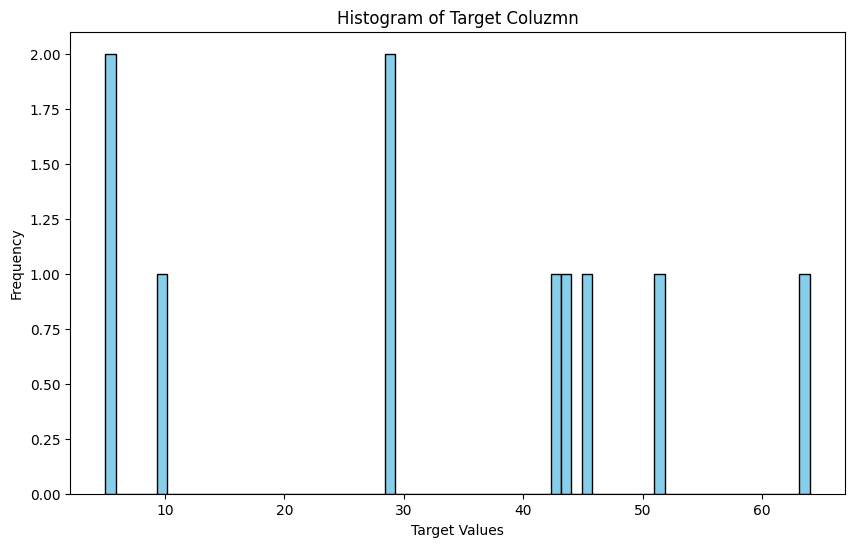

In [48]:
import matplotlib.pyplot as plt

# 设置图形大小
plt.figure(figsize=(10, 6))

# 绘制直方图
plt.hist(df['Target'], bins=68, color='skyblue', edgecolor='black')

# 添加标题和标签
plt.title('Histogram of Target Coluzmn')
plt.xlabel('Target Values')
plt.ylabel('Frequency')

# 显示图形
plt.show()

In [49]:
df_results_v=show_model_evaluate(valid_dl,valid_size,model_0,model_T,model_F,model_decision)
df_results_v

,Index,Target,Pred_F,Pred_T,Pred_0,Softmax_F,Softmax_T,Softmax_0,Softmax_decision,Match_F,Match_T,Match_0,Decision,flag
0,6003,84,51,84,84,0.989677,0.999536,0.987044,0.999782,False,True,True,True,True
1,3609,56,51,56,56,0.999931,1.000000,1.000000,0.999722,False,True,True,True,True
2,3923,62,45,62,62,0.883326,0.999959,0.999801,1.000000,False,True,True,True,True
3,5143,77,31,77,31,0.955008,0.999741,0.681327,0.765750,False,True,False,True,True
4,6809,95,31,95,95,0.750663,0.996890,0.882493,0.992301,False,True,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1469,1506,29,29,55,29,0.998417,0.620703,0.430306,0.851770,True,False,True,False,False
1470,4468,71,51,71,71,0.999858,1.000000,1.000000,1.000000,False,True,True,True,True
1471,6967,96,31,96,96,0.695321,1.000000,0.999997,1.000000,False,True,True,True,True
1472,3898,61,51,61,63,0.999933,0.812704,0.946556,0.868037,False,True,False,True,True


In [50]:
df_results_v[(df_results_v['Decision']!=df_results_v['flag'])]

,Index,Target,Pred_F,Pred_T,Pred_0,Softmax_F,Softmax_T,Softmax_0,Softmax_decision,Match_F,Match_T,Match_0,Decision,flag
126,2370,43,51,43,43,0.805654,0.995387,0.782092,0.866771,False,True,True,False,True
283,6746,94,29,34,31,0.775694,0.480656,0.412047,0.565885,False,False,False,False,True
287,4086,64,45,64,64,0.999938,0.999388,0.565364,0.756455,False,True,True,False,True
343,2368,43,51,43,43,0.999999,1.000000,0.974589,0.726093,False,True,True,False,True
566,529,10,45,10,10,0.626092,0.998911,0.992289,0.574740,False,True,True,False,True
612,2615,45,45,64,45,0.999994,0.955093,0.905885,0.918418,True,False,True,True,False
714,2655,45,45,44,45,0.999995,0.947567,0.950085,0.962100,True,False,True,True,False
765,1517,29,29,8,31,0.737388,0.446030,0.873940,0.592873,True,False,False,True,False
821,7111,98,51,98,51,1.000000,0.962576,0.847871,0.977201,False,True,False,False,True
837,2669,45,45,64,45,0.998974,0.795398,0.999834,0.552185,True,False,True,True,False


In [51]:
df=df_results_v[(df_results_v['Decision']!=df_results_v['flag'])]
target_counts = df['Target'].value_counts()
target_counts 

45    6
43    2
29    2
90    2
10    1
64    1
94    1
98    1
Name: Target, dtype: int64

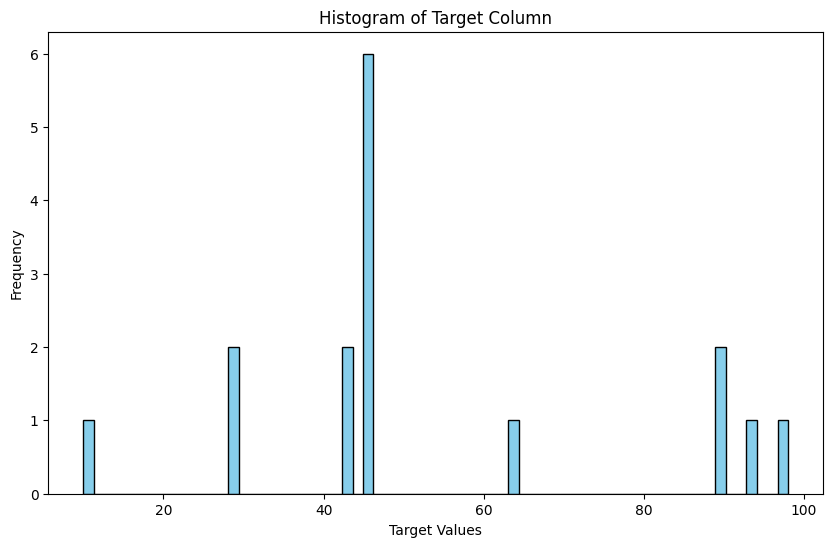

In [52]:
import matplotlib.pyplot as plt

# 设置图形大小
plt.figure(figsize=(10, 6))

# 绘制直方图
plt.hist(df['Target'], bins=68, color='skyblue', edgecolor='black')

# 添加标题和标签
plt.title('Histogram of Target Column')
plt.xlabel('Target Values')
plt.ylabel('Frequency')

# 显示图形
plt.show()